# Module 00 — SAR Theory Primer

This notebook is a **beginner-friendly reference** for the radar concepts used throughout Modules 01-06. It doesn't require any prior SAR background — every term is defined when it's first used, and equations are kept to the minimum needed to understand what the other notebooks compute.

**How to use this:** you don't have to read it start to finish before touching the other modules. Each section below says which module(s) put that idea into practice with real data, so you can jump back and forth. Where it's cheap to do, this notebook grounds the theory with real numbers pulled from your actual sample files (e.g. real radar wavelengths) or with a small synthetic simulation -- not just abstract formulas.

**Contents:**
1. What is SAR?
2. Wavelength, frequency, and radar bands
3. Imaging geometry (how a SAR image is formed)
4. The complex SLC pixel: amplitude and phase
5. Speckle -- and why we multilook
6. Backscatter and scattering mechanisms
7. Polarization and the covariance/correlation matrix
8. Repeat-pass imaging and backscatter change
9. InSAR: interferometric phase and displacement
10. Why L-band and S-band "see" the ground differently
11. Quick product primer: RSLC vs GCOV vs GUNW
12. Summary: concept -> module map

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SAMPLE_DATA_DIR = REPO_ROOT / "SampleData"

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import h5py

plt.rcParams["figure.dpi"] = 100
rng = np.random.default_rng(0)

## 1. What is SAR?

SAR stands for **Synthetic Aperture Radar**. Unlike an optical camera, it's an *active* sensor: the satellite transmits its own microwave pulses toward the ground and measures the signal that scatters back. Two consequences follow directly from that:

- It works day or night (it doesn't need sunlight).
- Microwaves pass through clouds largely unaffected, so SAR can image through cloud cover that would block an optical satellite.

"Synthetic Aperture" refers to how the along-track resolution is achieved: instead of needing a physically huge antenna, the satellite combines many echoes collected as it flies past a point on the ground to *synthesize* the equivalent of a much larger antenna. We won't derive that processing here -- what matters for this tutorial is the result: a high-resolution complex image, which is where Section 4 picks up.

## 2. Wavelength, frequency, and radar bands

A radar's wavelength is one of its most consequential design choices -- it's a large part of why Module 05 finds *different* backscatter behavior between the L-band and S-band files despite imaging the same ground.

Wavelength and frequency are related by the speed of light:

**lambda = c / f**   (lambda = wavelength, c = speed of light = 299,792,458 m/s, f = frequency in Hz)

NISAR carries two radars: an L-band instrument (LSAR) and an S-band instrument (SSAR, provided by ISRO). Rather than quoting textbook numbers, let's compute the real wavelengths from your own sample files' metadata:

In [2]:
with h5py.File(SAMPLE_DATA_DIR / "NISAR_L1_PR_RSLC_025_034_D_073_2005_DHDH_M_20260710T133917_20260710T133952_P05023_N_F_J_001.h5", "r") as h:
    f_l = h["science/LSAR/RSLC/swaths/frequencyA/acquiredCenterFrequency"][()]

with h5py.File(SAMPLE_DATA_DIR / "NISAR_S2_PR_GCOV_025_141_A_015_3700_DHNA_A_20260717T231346_20260717T231423_P00500_M_F_I_001.h5", "r") as h:
    f_s = h["science/SSAR/GCOV/metadata/sourceData/swaths/frequencyA/centerFrequency"][()]

c = 299_792_458.0
wavelength_l = c / f_l
wavelength_s = c / f_s

print(f"L-band (File 1): center frequency = {f_l/1e9:.3f} GHz  ->  wavelength = {wavelength_l*100:.1f} cm")
print(f"S-band (File 5): center frequency = {f_s/1e9:.3f} GHz  ->  wavelength = {wavelength_s*100:.1f} cm")

L-band (File 1): center frequency = 1.239 GHz  ->  wavelength = 24.2 cm
S-band (File 5): center frequency = 3.200 GHz  ->  wavelength = 9.4 cm


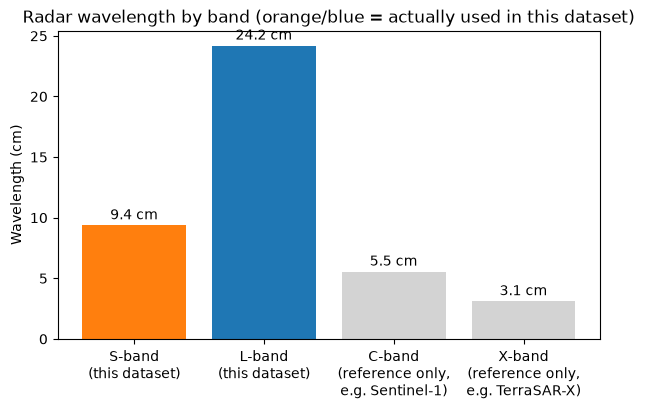

In [3]:
# For context only (not present in this dataset): two other common SAR bands.
reference_bands = {
    "S-band\n(this dataset)": wavelength_s * 100,
    "L-band\n(this dataset)": wavelength_l * 100,
    "C-band\n(reference only,\ne.g. Sentinel-1)": c / 5.405e9 * 100,
    "X-band\n(reference only,\ne.g. TerraSAR-X)": c / 9.65e9 * 100,
}

fig, ax = plt.subplots(figsize=(7, 4))
names = list(reference_bands.keys())
values = list(reference_bands.values())
colors = ["tab:orange", "tab:blue", "lightgray", "lightgray"]
ax.bar(names, values, color=colors)
ax.set_ylabel("Wavelength (cm)")
ax.set_title("Radar wavelength by band (orange/blue = actually used in this dataset)")
for i, v in enumerate(values):
    ax.text(i, v + 0.5, f"{v:.1f} cm", ha="center")
plt.show()

Shorter wavelength (S-band, X-band) means the wave interacts more with small objects near the surface (leaves, small branches, surface roughness at a fine scale). Longer wavelength (L-band) tends to penetrate further into vegetation canopy and is more sensitive to larger structures (branches, trunks) or, over sparse vegetation, the ground beneath. We'll come back to this in Section 10, and it's demonstrated with real data in **Module 05**.

## 3. Imaging geometry: how a SAR image is formed

SAR is a **side-looking** instrument -- it images off to one side of the satellite's ground track, not straight down (looking straight down would make it impossible to tell whether a returning echo came from the left or right side of the track). This gives us two image dimensions that are fundamentally different from a camera's:

- **Range**: the direction across the swath, away from the satellite's ground track. Distance in this direction is measured directly from the round-trip travel time of the radar pulse.
- **Azimuth**: the direction along the satellite's flight track. Resolution in this direction comes from the "synthetic aperture" processing mentioned in Section 1.

The **incidence angle** is the angle between the radar's line of sight and the local vertical (surface normal) at the ground point. It varies across the swath and matters a lot: the same physical surface can look different in backscatter at different incidence angles, which is why radiometric terrain correction is on every module's "what real-world deployment would require" list.

The diagram below is a simplified, not-to-scale side view (looking along the flight track) -- the azimuth/flight direction runs perpendicular to the page.

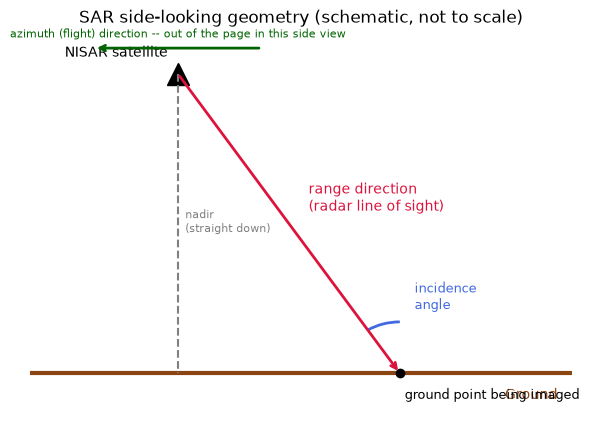

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_xlim(-1, 10)
ax.set_ylim(-1, 8)
ax.axis("off")

ax.plot([-1, 10], [0, 0], color="saddlebrown", linewidth=3)
ax.text(9.7, -0.6, "Ground", ha="right", color="saddlebrown")

sat_x, sat_y = 2.0, 7.0
ground_x = 6.5

ax.plot(sat_x, sat_y, marker="^", markersize=16, color="black")
ax.text(sat_x - 0.2, sat_y + 0.4, "NISAR satellite", ha="right")

ax.plot([sat_x, sat_x], [sat_y, 0], linestyle="--", color="gray")
ax.text(sat_x + 0.15, 3.3, "nadir\n(straight down)", color="gray", fontsize=8)

ax.annotate("", xy=(ground_x, 0), xytext=(sat_x, sat_y), arrowprops=dict(arrowstyle="->", color="crimson", linewidth=2))
ax.text((sat_x + ground_x) / 2 + 0.4, sat_y / 2 + 0.3, "range direction\n(radar line of sight)", color="crimson")

dx, dy = sat_x - ground_x, sat_y - 0
angle_to_sat = np.degrees(np.arctan2(dy, dx))
arc = patches.Arc((ground_x, 0), 2.4, 2.4, angle=0, theta1=90, theta2=angle_to_sat, color="royalblue", linewidth=2)
ax.add_patch(arc)
ax.text(ground_x + 0.3, 1.5, "incidence\nangle", color="royalblue", fontsize=9)

ax.plot(ground_x, 0, marker="o", color="black")
ax.text(ground_x + 0.1, -0.6, "ground point being imaged", ha="left", fontsize=9)

ax.annotate("", xy=(0.3, 7.6), xytext=(3.7, 7.6), arrowprops=dict(arrowstyle="->", color="darkgreen", linewidth=2))
ax.text(2.0, 7.85, "azimuth (flight) direction -- out of the page in this side view", color="darkgreen", ha="center", fontsize=8)

ax.set_title("SAR side-looking geometry (schematic, not to scale)")
plt.show()

## 4. The complex SLC pixel: amplitude and phase

RSLC ("Range Doppler SLC" -- Single Look Complex) products, used in **Module 01**, store each pixel as a **complex number**: `z = I + iQ`, equivalently written as `z = A * exp(i * phi)` where:

- **Amplitude (A = |z|)**: how strongly the target reflected the radar signal. This is what most SAR "images" show, and is closely related to the physical backscatter strength.
- **Phase (phi = angle of z)**: related to the precise distance from the sensor to the target, modulo one wavelength. A single pixel's absolute phase isn't meaningful on its own (it's essentially random from pixel to pixel -- more on that in Section 5) -- but the *difference* in phase between two acquisitions of the same pixel is exactly what InSAR (Section 9, Module 04) uses to measure ground motion.

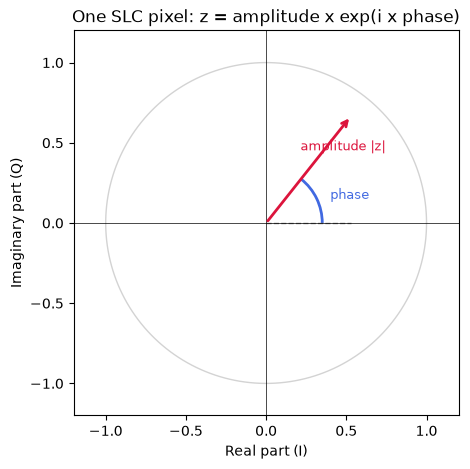

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color="lightgray", linewidth=1)

amp, phase = 0.85, 0.9
x, y = amp * np.cos(phase), amp * np.sin(phase)
ax.annotate("", xy=(x, y), xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="crimson", linewidth=2))
ax.plot([0, x], [0, 0], linestyle="--", color="gray", linewidth=1)
arc = patches.Arc((0, 0), 0.7, 0.7, angle=0, theta1=0, theta2=np.degrees(phase), color="royalblue", linewidth=2)
ax.add_patch(arc)
ax.text(x / 2 - 0.05, y / 2 + 0.12, "amplitude |z|", color="crimson", fontsize=9)
ax.text(0.4, 0.15, "phase", color="royalblue", fontsize=9)

ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.set_xlabel("Real part (I)")
ax.set_ylabel("Imaginary part (Q)")
ax.set_title("One SLC pixel: z = amplitude x exp(i x phase)")
plt.show()

## 5. Speckle -- and why we multilook

SAR intensity images look grainy even over a physically uniform surface. This **speckle** isn't sensor noise in the usual sense -- it's a real interference effect: each pixel's return is the coherent sum of many sub-pixel-scale scatterers, and small differences in their relative phase cause the summed amplitude to fluctuate randomly from pixel to pixel, even when the underlying surface is uniform.

For **fully developed speckle** (an idealization: many random, independent, similar-strength scatterers per pixel), single-look intensity has a coefficient of variation (CV = std/mean) of **~1.0**. Averaging N independent looks (multilooking) reduces that to approximately **1/sqrt(N)** -- at the cost of spatial resolution, since each output pixel now represents a larger ground area.

Let's verify this with a quick synthetic simulation (no real data needed) before checking it against real NISAR data in **Module 01**:

Synthetic fully-developed speckle -- coefficient of variation vs. number of looks:
  1x1 block (  1 total looks): CV = 1.003   (theory: 1/sqrt(1) = 1.000)
  2x2 block (  4 total looks): CV = 0.502   (theory: 1/sqrt(4) = 0.500)
  4x4 block ( 16 total looks): CV = 0.251   (theory: 1/sqrt(16) = 0.250)
  8x8 block ( 64 total looks): CV = 0.125   (theory: 1/sqrt(64) = 0.125)
  16x16 block (256 total looks): CV = 0.063   (theory: 1/sqrt(256) = 0.062)


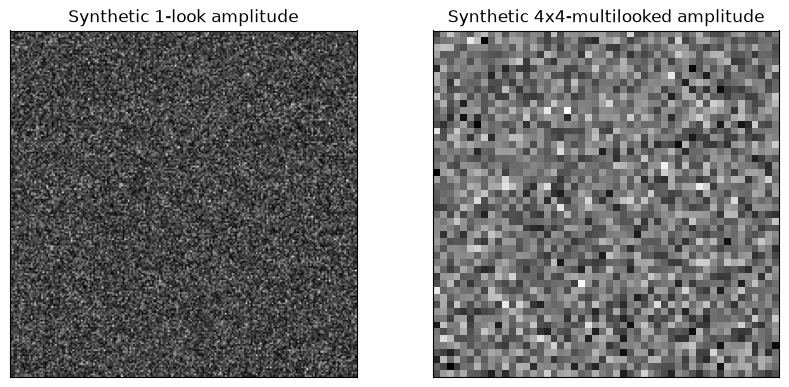

In [6]:
# Simulate fully-developed speckle: single-look intensity of uniform-reflectivity
# terrain follows an exponential distribution (a standard SAR speckle model).
true_mean_intensity = 1.0
sim_intensity = rng.exponential(scale=true_mean_intensity, size=(800, 800))

def multilook(arr, looks_row, looks_col):
    n_rows = (arr.shape[0] // looks_row) * looks_row
    n_cols = (arr.shape[1] // looks_col) * looks_col
    trimmed = arr[:n_rows, :n_cols]
    reshaped = trimmed.reshape(n_rows // looks_row, looks_row, n_cols // looks_col, looks_col)
    return reshaped.mean(axis=(1, 3))

print("Synthetic fully-developed speckle -- coefficient of variation vs. number of looks:")
for block in (1, 2, 4, 8, 16):
    ml = sim_intensity if block == 1 else multilook(sim_intensity, block, block)
    total_looks = block * block
    cv = ml.std() / ml.mean()
    print(f"  {block}x{block} block ({total_looks:3d} total looks): CV = {cv:.3f}   "
          f"(theory: 1/sqrt({total_looks}) = {1/np.sqrt(total_looks):.3f})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(np.sqrt(sim_intensity[:200, :200]), cmap="gray")
axes[0].set_title("Synthetic 1-look amplitude")
axes[1].imshow(np.sqrt(multilook(sim_intensity, 4, 4)[:50, :50]), cmap="gray")
axes[1].set_title("Synthetic 4x4-multilooked amplitude")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

This matches theory closely, because the simulation is an idealized case (independent, identically distributed samples by construction). Real terrain is messier -- **Module 01** repeats this exact check on real RSLC data and finds the CV starts higher and decays more slowly than this idealized curve, because real agricultural land has genuine small-scale texture (field microstructure, furrows) that isn't pure speckle. That gap between idealized theory and real behavior is itself worth understanding, not a failure of the theory.

## 6. Backscatter and scattering mechanisms

How much energy scatters back to the radar -- and how it's distributed between polarizations -- depends on the physical structure of what it hits. Three idealized mechanisms are commonly used to reason about this qualitatively (this is a simplification; real targets are usually a mix):

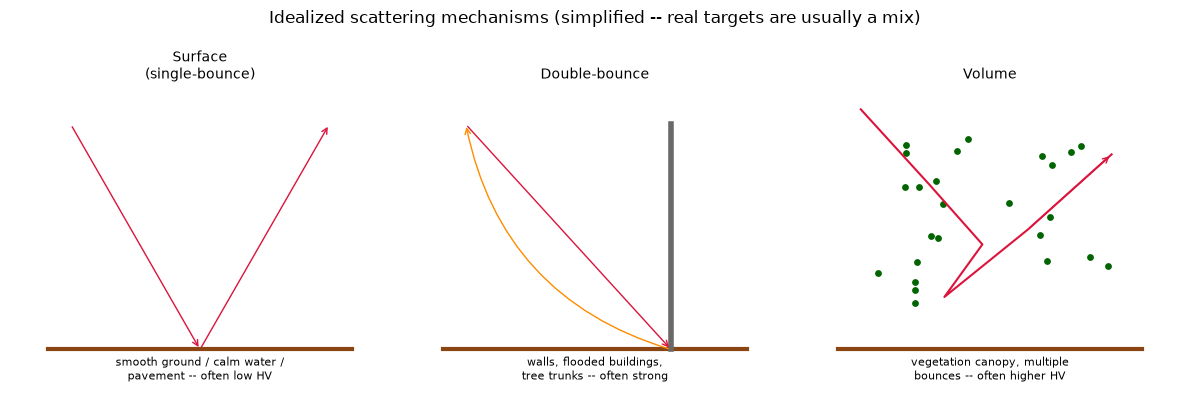

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Surface (single-bounce) scattering
ax = axes[0]
ax.plot([0, 4], [0, 0], color="saddlebrown", linewidth=3)
ax.annotate("", xy=(2, 0), xytext=(0.3, 3), arrowprops=dict(arrowstyle="->", color="crimson"))
ax.annotate("", xy=(3.7, 3), xytext=(2, 0), arrowprops=dict(arrowstyle="->", color="crimson"))
ax.set_xlim(-0.5, 4.5); ax.set_ylim(-0.5, 3.5); ax.axis("off")
ax.set_title("Surface\n(single-bounce)", fontsize=10)
ax.text(2, -0.4, "smooth ground / calm water /\npavement -- often low HV", ha="center", fontsize=8)

# Double-bounce scattering
ax = axes[1]
ax.plot([0, 4], [0, 0], color="saddlebrown", linewidth=3)
ax.plot([3, 3], [0, 3], color="dimgray", linewidth=4)
ax.annotate("", xy=(3, 0), xytext=(0.3, 3), arrowprops=dict(arrowstyle="->", color="crimson"))
ax.annotate("", xy=(0.3, 3), xytext=(3, 0), arrowprops=dict(arrowstyle="->", color="darkorange", connectionstyle="arc3,rad=-0.3"))
ax.set_xlim(-0.5, 4.5); ax.set_ylim(-0.5, 3.5); ax.axis("off")
ax.set_title("Double-bounce", fontsize=10)
ax.text(2, -0.4, "walls, flooded buildings,\ntree trunks -- often strong", ha="center", fontsize=8)

# Volume scattering
ax = axes[2]
ax.plot([0, 4], [0, 0], color="saddlebrown", linewidth=3)
canopy_pts = rng.uniform([0.3, 0.5], [3.7, 2.8], size=(25, 2))
ax.scatter(canopy_pts[:, 0], canopy_pts[:, 1], color="darkgreen", s=15)
path_x = [0.3, 1.2, 1.9, 1.4, 2.5, 3.6]
path_y = [3.2, 2.2, 1.4, 0.7, 1.6, 2.6]
ax.plot(path_x, path_y, color="crimson", linewidth=1.5)
ax.annotate("", xy=(path_x[-1], path_y[-1]), xytext=(path_x[-2], path_y[-2]), arrowprops=dict(arrowstyle="->", color="crimson"))
ax.set_xlim(-0.5, 4.5); ax.set_ylim(-0.5, 3.5); ax.axis("off")
ax.set_title("Volume", fontsize=10)
ax.text(2, -0.4, "vegetation canopy, multiple\nbounces -- often higher HV", ha="center", fontsize=8)

fig.suptitle("Idealized scattering mechanisms (simplified -- real targets are usually a mix)")
plt.tight_layout()
plt.show()

A commonly used qualitative shortcut: surfaces dominated by surface/double-bounce scattering tend toward a *higher* HH/HV power ratio, while more depolarizing volume scattering tends toward a *lower* ratio. **Module 03** computes this ratio from real GCOV data and builds a (deliberately unvalidated, illustrative-only) threshold split from it.

## 7. Polarization and the covariance/correlation matrix

NISAR transmits and receives specific polarizations (e.g. H = horizontal, V = vertical). "HH" means horizontal transmit, horizontal receive; "HV" means horizontal transmit, vertical receive, and so on. A **dual-pol** product (like all the GCOV samples here) transmits one polarization (H) and receives both (H and V).

For a pixel with both HH and HV, we can form a small **covariance matrix**:

```
[ <HH * conj(HH)>     <HH * conj(HV)> ]
[ <HV * conj(HH)>     <HV * conj(HV)> ]
```

- The **diagonal** terms (HHHH, HVHV) are just the power in each channel -- always real, non-negative.
- The **off-diagonal** term (HHHV) is the *correlation* between the two channels -- a complex number, since it carries both a magnitude and a relative phase.

This directly explains a design choice used throughout Modules 03-06: **File 3's GCOV product only has the diagonal terms**, so only a power ratio is possible; **File 5's GCOV product also has HHHV**, so a correlation coefficient can be computed:

**rho = HHHV / sqrt(HHHH * HVHV)**, with `|rho|` in [0, 1].

There's a subtlety worth knowing about *before* you see it happen in Module 06: `rho` estimated from a **small number of samples is a biased estimator** -- when the true correlation is low, a limited-sample estimate is still pulled upward, and that bias shrinks as more independent samples are averaged in. Let's demonstrate this cleanly with synthetic data, where we control the *true* correlation ourselves:

In [8]:
def simulate_correlated_pair(true_rho_mag, n_samples, rng):
    """Simulate n_samples of two correlated complex Gaussian channels with a known
    true correlation magnitude, then return the *sample* correlation magnitude."""
    cov = np.array([[1.0, true_rho_mag], [true_rho_mag, 1.0]])
    L = np.linalg.cholesky(cov)
    z = rng.standard_normal((2, n_samples)) + 1j * rng.standard_normal((2, n_samples))
    correlated = L @ z
    ch1, ch2 = correlated[0], correlated[1]
    sample_rho = np.mean(ch1 * np.conj(ch2)) / np.sqrt(np.mean(np.abs(ch1) ** 2) * np.mean(np.abs(ch2) ** 2))
    return np.abs(sample_rho)

true_rho = 0.1  # deliberately LOW true correlation
print(f"True correlation magnitude (by construction): {true_rho}")
print("Sample-estimated |rho| vs. number of samples averaged (repeated 2000x each, showing the mean estimate):")
for n_samples in (1, 4, 16, 64, 256):
    estimates = [simulate_correlated_pair(true_rho, n_samples, rng) for _ in range(2000)]
    print(f"  {n_samples:3d} samples: mean estimated |rho| = {np.mean(estimates):.3f}  (true value: {true_rho})")

True correlation magnitude (by construction): 0.1
Sample-estimated |rho| vs. number of samples averaged (repeated 2000x each, showing the mean estimate):
    1 samples: mean estimated |rho| = 1.000  (true value: 0.1)
    4 samples: mean estimated |rho| = 0.464  (true value: 0.1)
   16 samples: mean estimated |rho| = 0.244  (true value: 0.1)
   64 samples: mean estimated |rho| = 0.142  (true value: 0.1)
  256 samples: mean estimated |rho| = 0.109  (true value: 0.1)


With only 1 sample, the estimated correlation is heavily biased upward -- nowhere near the true value of 0.1. It only approaches the true value once enough independent samples are averaged. **Module 06** finds exactly this pattern in real S-band GCOV data: the per-pixel HH-HV correlation estimate drops substantially as more spatial averaging (multilooking) is applied, which is this same bias effect, not a change in the real scene.

## 8. Repeat-pass imaging and backscatter change

Flying the same track/frame repeatedly lets us compare backscatter at (approximately) the same imaging geometry across two dates -- the basis of **Module 02**'s change-detection demo. Two real-world complications show up immediately once you try this:

- **Geometric coregistration**: the two acquisitions' pixel grids may not be perfectly aligned, or may even have different sample spacing (as Module 02 finds between its two files, which were processed with different range bandwidths). Pixels have to be matched to the same ground location before differencing makes sense.
- **Radiometric consistency**: even after geometric alignment, backscatter differences can arise from calibration differences between acquisitions, not just real ground change. Module 02 finds a clear example of this.

A raw backscatter difference map is only a first step -- distinguishing genuine land-cover change from calibration artifacts, soil moisture, or ordinary speckle requires the additional context listed in Module 02's closing cell.

## 9. InSAR: interferometric phase and displacement

**InSAR** (Interferometric SAR) uses the *phase difference* between two SAR acquisitions of the same area to measure the path-length difference between them, which -- for a repeat-pass pair -- includes any ground motion that occurred between the two dates. This is what **Module 04**'s GUNW product provides.

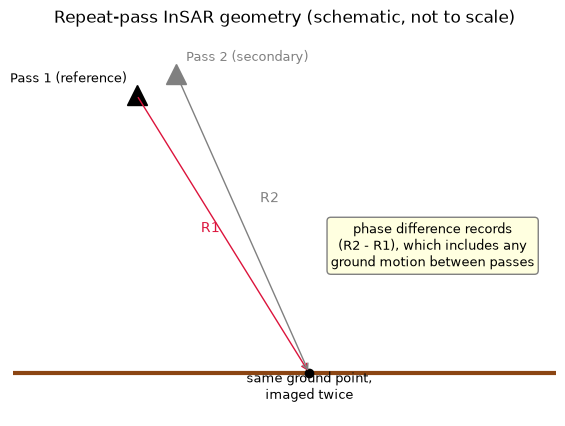

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_xlim(-1, 10)
ax.set_ylim(-1, 8)
ax.axis("off")

ax.plot([-1, 10], [0, 0], color="saddlebrown", linewidth=3)
ground_x = 5.0
ax.plot(ground_x, 0, marker="o", color="black")
ax.text(ground_x, -0.6, "same ground point,\nimaged twice", ha="center", fontsize=9)

sat1 = (1.5, 6.5)
sat2 = (2.3, 7.0)
ax.plot(*sat1, marker="^", markersize=14, color="black")
ax.plot(*sat2, marker="^", markersize=14, color="gray")
ax.text(sat1[0] - 0.2, sat1[1] + 0.3, "Pass 1 (reference)", ha="right", fontsize=9)
ax.text(sat2[0] + 0.2, sat2[1] + 0.3, "Pass 2 (secondary)", ha="left", fontsize=9, color="gray")

ax.annotate("", xy=(ground_x, 0), xytext=sat1, arrowprops=dict(arrowstyle="->", color="crimson"))
ax.annotate("", xy=(ground_x, 0), xytext=sat2, arrowprops=dict(arrowstyle="->", color="gray"))
ax.text(2.8, 3.3, "R1", color="crimson")
ax.text(4.0, 4.0, "R2", color="gray")

ax.text(7.5, 2.5, "phase difference records\n(R2 - R1), which includes any\nground motion between passes",
        ha="center", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))

ax.set_title("Repeat-pass InSAR geometry (schematic, not to scale)")
plt.show()

The raw interferometric phase is a mix of several contributions, only one of which is deformation:

**phi_total = phi_flat-earth + phi_topography + phi_deformation + phi_atmosphere + phi_ionosphere + phi_noise**

Producing a *displacement* map means removing everything except `phi_deformation`. GUNW products already remove the flat-earth and topographic terms using a reference DEM, but atmospheric delay, ionospheric delay, noise, and unwrapping errors remain -- which is exactly what Module 04 finds and has to reason through.

The `phi_atmosphere` and `phi_ionosphere` terms are worth distinguishing, especially for NISAR: ionospheric phase delay scales with the *square* of the radar wavelength, so L-band (NISAR's band, ~24 cm) is far more susceptible to it than the shorter wavelengths used by C-band (e.g. Sentinel-1, ~5.6 cm) or X-band systems -- the same ionospheric total electron content produces a much larger phase error at L-band. This is why NISAR's GUNW product includes a dedicated `ionospherePhaseScreen` layer (derived via split-spectrum processing) rather than leaving ionosphere lumped in with generic "atmosphere" -- Module 04 uses it directly to check whether a large observed phase gradient is ionospheric rather than tropospheric or orbital in origin.

Once you have a "clean" deformation phase, converting it to a physical line-of-sight distance uses the same wavelength concept from Section 2:

**displacement = phi_deformation * lambda / (4*pi)**

For example, using this dataset's real L-band wavelength, one full 2*pi cycle of deformation phase corresponds to:

In [10]:
one_cycle_displacement_cm = wavelength_l / 2 * 100  # lambda/2 per 2*pi cycle, in cm
print(f"L-band wavelength: {wavelength_l*100:.1f} cm")
print(f"One full 2*pi phase cycle = lambda/2 = {one_cycle_displacement_cm:.1f} cm of line-of-sight displacement")
print()

# Module 04's actual reported valid-pixel unwrapped phase range (min=-66.51, max=1.66 rad).
module04_phase_span_rad = 1.66 - (-66.51)
apparent_displacement_cm = module04_phase_span_rad * wavelength_l / (4 * np.pi) * 100
print(f"Module 04's real unwrapped phase spans about {module04_phase_span_rad:.0f} radians across its valid pixels")
print(f"(from -66.51 to 1.66 rad). Taken at face value, that would convert to roughly "
      f"{apparent_displacement_cm:.0f} cm of apparent displacement --")
print("which is exactly why Module 04 concludes that gradient is far too large to be real")
print("ground motion from a single 12-day pair. Module 04 checks this gradient against the")
print("product's own ionospherePhaseScreen layer and finds a strong quantitative match (r ~= 0.93),")
print("consistent with the L-band ionospheric susceptibility described above.")

L-band wavelength: 24.2 cm
One full 2*pi phase cycle = lambda/2 = 12.1 cm of line-of-sight displacement

Module 04's real unwrapped phase spans about 68 radians across its valid pixels
(from -66.51 to 1.66 rad). Taken at face value, that would convert to roughly 131 cm of apparent displacement --
which is exactly why Module 04 concludes that gradient is far too large to be real
ground motion from a single 12-day pair. Module 04 checks this gradient against the
product's own ionospherePhaseScreen layer and finds a strong quantitative match (r ~= 0.93),
consistent with the L-band ionospheric susceptibility described above.


## 10. Why L-band and S-band "see" the ground differently

Tying Sections 2 and 6 together: a wave interacts most strongly with objects comparable in size to its own wavelength. With this dataset's real wavelengths (L-band ~24 cm, S-band ~9 cm):

- **S-band** (shorter wavelength) is more sensitive to smaller-scale surface roughness and near-surface vegetation elements (leaves, small branches), and tends to penetrate less deeply into a canopy.
- **L-band** (longer wavelength) penetrates further into vegetation and is more sensitive to larger woody structure, or -- over sparse vegetation -- the ground surface underneath.

This is general SAR physics, not a claim about the specific land cover in any of this repo's sample scenes. **Module 05** compares real L-band and S-band backscatter over the same confirmed ground footprint, and **Module 06** uses the extra polarimetric information (Section 7) available only in the S-band sample.

## 11. Quick product primer: RSLC vs GCOV vs GUNW

- **RSLC** (L1, Range Doppler Single Look Complex): complex SLC data in radar (range/azimuth) coordinates -- not geocoded. Full resolution, but you need the product's own geolocation grid to relate a pixel to a ground location. Used in **Modules 01-02**.
- **GCOV** (L2, Geocoded Covariance): backscatter power (and, when present, cross-channel correlation) resampled onto a map projection (a UTM zone, in this dataset), with direct x/y coordinate axes. Used in **Modules 03, 05, 06**.
- **GUNW** (L2, Geocoded Unwrapped interferogram): the interferometric product formed from a *pair* of RSLC acquisitions -- unwrapped phase, coherence, and connected-component layers, geocoded like GCOV. Used in **Module 04**.

A fuller product-level glossary lives in `docs/product_guide.md`.

## 12. Summary: concept -> module map

| Theory concept (this notebook) | Demonstrated with real data in |
|---|---|
| Wavelength/frequency, radar bands (Section 2) | Module 05 |
| Imaging geometry, incidence angle (Section 3) | Module 01 |
| Complex SLC pixel: amplitude & phase (Section 4) | Module 01 |
| Speckle statistics and multilooking (Section 5) | Module 01 |
| Scattering mechanisms, HH/HV ratio (Section 6) | Module 03 |
| Covariance matrix, correlation coefficient, estimator bias (Section 7) | Module 06 |
| Repeat-pass backscatter change, coregistration (Section 8) | Module 02 |
| InSAR phase, coherence, phase-to-displacement (Section 9) | Module 04 |
| Frequency-dependent scattering, L vs S band (Section 10) | Module 05, Module 06 |

## What this notebook is not

Like every other module in this repo, this is a conceptual/technique primer, not a substitute for a SAR remote sensing textbook or course. Derivations (e.g. of the synthetic aperture processing itself, or a full radar equation) are intentionally omitted -- the goal here is just enough working understanding to make sense of what Modules 01-06 compute and why.